# ADK によるエージェント開発入門・チュートリアル

Gemini 3 対応バージョン

## 事前準備

ADK の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

In [ ]:
%pip install --upgrade --user \
    google-adk==1.36.1 \
    google-genai==2.11.0 \
    google-cloud-aiplatform==1.160.0

インストールされたパッケージのバージョンを確認します。

下記の内容が表示されることを確認してください。

```
google-adk                               1.36.1
google-cloud-aiplatform                  1.160.0
google-genai                             2.11.0
```

In [1]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform)"

google-adk                               1.36.1
google-cloud-aiplatform                  1.160.0
google-genai                             2.11.0


カーネルを再起動して、インストールしたパッケージを利用可能にします。

次のコマンドを実行すると確認のポップアップが表示されます。

In [10]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## ADK Agent の作成

必要なモジュールをインポートして、Vertex AI の環境を初期化します。

In [1]:
import copy
import datetime
import json
import os
import pprint
from functools import cached_property
from IPython.display import HTML, Markdown, display

import vertexai
from google.adk.agents.llm_agent import LlmAgent
from google.adk.models import Gemini
from google.adk.tools import google_search
from google.genai import Client
#from google.genai.types import Content, Part
from vertexai.agent_engines import AdkApp

# Initialize Vertex AI
[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'
vertexai.init(project=PROJECT_ID, location=LOCATION)

os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

/home/jupyter/.local/lib/python3.10/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


`LlmAgent` オブジェクト、および、それを含んだ `AdkApp` オブジェクトを定義します。

In [2]:
instruction = '''
あなたはユーザーの質問に回答するエージェントです。
- google_search を使用して、最新情報に基づいて回答してください。
- [1][2] のような引用番号は付けないで、日本語の回答をマークダウン形式で出力してください。
- フレンドリーな会話を心がけてください。
'''

search_agent = LlmAgent(
    name='search_agent',
    model='gemini-3.1-flash-lite',
    description='Google Search を用いて質問に回答するエージェント',
    instruction=instruction,
    tools=[google_search],
)

search_agent_app = AdkApp(
    agent=search_agent,
    app_name='search_agent_app',
)

`AdkApp` オブジェクトを通してエージェントと会話する簡易アプリのクラスを定義します。

In [3]:
# Chat client to test AdkApp
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

## 実行例

簡単な質問をしてみます。

In [4]:
chat_client = ChatClient(search_agent_app)

query = '''
高田馬場のおすすめのカレー屋は？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

高田馬場は「カレーの激戦区」として有名で、個性的で美味しいカレー屋さんがたくさんありますよ！いくつかおすすめをご紹介しますね。

### 人気の定番・有名店
* **横浜ボンベイ 高田馬場店**
    サラッとしたルーが特徴の人気店です。特に「カシミールカレー」は長年愛されている超有名メニュー。極辛口でありながら、野菜の甘みやスパイスの爽快感が絶妙で、一度食べたら忘れられない美味しさです。
* **カリーライス専門店 エチオピア 高田馬場店**
    長時間煮込んだ野菜の旨味が溶け込んだ、コクのあるカレーが楽しめます。スパイスの効いた本格的なカレーが食べたい時におすすめです。

### ユニークなお店・隠れ家
* **Curry kitchen CACA（カカ）**
    ランチ・ディナー・深夜食堂として営業している隠れ家的なお店です。看板メニューの「牛すじカレー」や、ほかではなかなか出会えない「カレー炒飯」など、創作的なメニューが充実しています。お酒と一緒に楽しむのも良いですね。
* **アプサラ**
    スリランカカレーが楽しめる人気店です。スリランカカレーならではの、スパイスの香りと食材の組み合わせが楽しめます。

### そのほか
* **Biryani Tokyo**
    インド料理やビリヤニがお好きな方には非常に評価の高いお店です。

高田馬場には、他にもインドカレーやスープカレーなど多種多様なお店が揃っています。その日の気分に合わせて、ぜひお気に入りを見つけてみてくださいね！

`AdkApp` オブジェクトは、ユーザー ID とセッション ID でセッション情報を管理しています。

先ほどの会話のユーザー ID とセッション ID を確認します。

In [5]:
user_id = chat_client.user_id
session_id = chat_client.session_id

print(f'User ID: {user_id}\nSession ID: {session_id}')

session = await chat_client.adk_app.async_get_session(
    user_id = user_id,
    session_id = session_id,
)

User ID: default_user
Session ID: 177abb07-8204-47b8-8192-d015c547fcc4


ユーザー ID とセッション ID を指定して、セッション情報を取得します。

取得したセッション情報は `Session` オブジェクト形式になっています。Agent Engine を利用した場合との互換性のために、ここでは、Python の辞書形式に変換しています。

In [6]:
def session_to_dict(session):
    def to_camel_case(snake_str):
        components = snake_str.split('_')
        return components[0] + ''.join(x.capitalize() for x in components[1:])
    def camel_case_keys(d):
        return {to_camel_case(k): v for k, v in d.items()}
    return json.loads(session.model_dump_json(), object_hook=camel_case_keys)

session_dict = session_to_dict(session)

`session_dict` のキーを確認します。

In [7]:
session_dict.keys()

dict_keys(['id', 'appName', 'userId', 'state', 'events', 'lastUpdateTime'])

`session_dict['events']` には、これまでの会話の情報を表す `Event` オブジェクトのリストが含まれています。

In [8]:
print(f"Number of events: {len(session_dict['events'])}")
print('====')
pprint.pp(session_dict['events'])

Number of events: 2
====
[{'modelVersion': None,
  'content': {'parts': [{'mediaResolution': None,
                         'codeExecutionResult': None,
                         'executableCode': None,
                         'fileData': None,
                         'functionCall': None,
                         'functionResponse': None,
                         'inlineData': None,
                         'text': '\n高田馬場のおすすめのカレー屋は？\n',
                         'thought': None,
                         'thoughtSignature': None,
                         'videoMetadata': None,
                         'toolCall': None,
                         'toolResponse': None,
                         'partMetadata': None}],
              'role': 'user'},
  'groundingMetadata': None,
  'partial': None,
  'turnComplete': None,
  'turnCompleteReason': None,
  'finishReason': None,
  'errorCode': None,
  'errorMessage': None,
  'interrupted': None,
  'customMetadata': None,
  'usageMetadata': None,

`Event` オブジェクトに含まれる `timestamp` と `author` をダンプすると、会話の流れがわかります。

In [9]:
def format_timestamp(ts):
    return datetime.datetime.fromtimestamp(ts).strftime('%Y-%m-%d %H:%M:%S.%f')

for event in session_dict['events']:
    print(format_timestamp(event['timestamp']), event['author'])

2026-07-14 10:09:10.569138 user
2026-07-14 10:09:10.613497 search_agent


`Event` オブジェクトには、エージェントが Google 検索に利用したキーワードなども含まれています。

In [10]:
search_queries = session_dict['events'][1]['groundingMetadata']['webSearchQueries']
entry_point_html = session_dict['events'][1]['groundingMetadata']['searchEntryPoint']['renderedContent']

print(search_queries)
display(HTML(entry_point_html))

['高田馬場 おすすめ カレー屋']


会話を続けると、セッションに `Event` オブジェクトが追加されていきます。

In [11]:
query = '''
特に家族連れにおすすめなのは？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

高田馬場のカレー店はカウンターのみのコンパクトなお店も多いですが、ご家族で利用しやすいお店もいくつかあります。

ご家族連れであれば、以下のような視点で選ぶのがおすすめです。

### 家族連れにおすすめのお店

* **Namaste Asian Dining & Bar（ナマステ）高田馬場**
  * **おすすめポイント:** テーブル席が充実しており、広々とした空間でゆったり過ごしやすいのが魅力です。インドカレーのお店なので、辛さ調整ができるメニューも多く、お子様でも安心して一緒に食事が楽しめます。
* **カレーハウスCoCo壱番屋 新宿高田馬場店**
  * **おすすめポイント:** 家族連れの定番ですが、やはりテーブル席があり、メニューも豊富で辛さや量の調整が細かくできる点は安心感があります。外食に慣れていないお子様が一緒でも入りやすい雰囲気です。

### 家族連れで利用する際のヒント

高田馬場で人気の「ブラザー」や「プネウマカレー」といった有名店は、非常に美味しいのですが、カウンター席のみでスペースが限られており、常に行列ができていることが多いです。小さなお子様連れの場合は、**「テーブル席があるか」「混雑状況」**を事前に確認するか、少し時間をずらして訪れるのがコツです。

また、もしカレーにこだわりつつ「みんなでゆったり食事がしたい」という場合は、カレー専門店に限定せず、**インド料理レストラン（ダイニングバー形式）**を探すと、テーブル席が多く、ベビーカーの入店に対応してくれるお店が見つかりやすいですよ！

お出かけ当日の状況に合わせて、無理のないお店を選んでみてくださいね。

In [12]:
session = await chat_client.adk_app.async_get_session(
    user_id = user_id,
    session_id = session_id,
)
session_dict = session_to_dict(session)

for event in session_dict['events']:
    print(format_timestamp(event['timestamp']), event['author'])

2026-07-14 10:09:10.569138 user
2026-07-14 10:09:10.613497 search_agent
2026-07-14 10:09:17.101342 user
2026-07-14 10:09:17.104439 search_agent


In [13]:
search_queries = session_dict['events'][-1]['groundingMetadata']['webSearchQueries']
entry_point_html = session_dict['events'][-1]['groundingMetadata']['searchEntryPoint']['renderedContent']

print(search_queries)
display(HTML(entry_point_html))

['高田馬場 カレー 家族連れ おすすめ', '高田馬場 カレー屋 子供連れ 入店しやすい', '高田馬場 カレー テーブル席あり 家族']


## LLM が受け取るプロンプトの確認

ADK が Gemini API を呼び出す関数を修正して、API に送信するプロンプトの内容を表示します。

In [14]:
from google.adk.agents.invocation_context import InvocationContext
from typing import AsyncGenerator
from google.adk.events.event import Event
from google.adk.models.llm_request import LlmRequest

async def _run_one_step_async(
      self,
      invocation_context: InvocationContext,
  ) -> AsyncGenerator[Event, None]:
    """One step means one LLM call."""
    llm_request = LlmRequest()

    # Preprocess before calling the LLM.
    async for event in self._preprocess_async(invocation_context, llm_request):
        yield event
    if invocation_context.end_invocation:
        return

    # Calls the LLM.
    model_response_event = Event(
        id=Event.new_id(),
        invocation_id=invocation_context.invocation_id,
        author=invocation_context.agent.name,
        branch=invocation_context.branch,
    )

    ## DEBUG output
    if DEBUG:
        print('## Prompt contents ##')
        pprint.pp(llm_request.contents)
        print('----')
        print('## System instruction ##')
        print(llm_request.config.system_instruction)
        print('----')
        print('## Tools config ##')
        pprint.pp(llm_request.config.tools)
        print('----')
    ####

    async for llm_response in self._call_llm_async(
        invocation_context, llm_request, model_response_event
    ):
        # Postprocess after calling the LLM.
        async for event in self._postprocess_async(
            invocation_context, llm_request, llm_response, model_response_event
        ):
            yield event

from google.adk.flows.llm_flows.base_llm_flow import BaseLlmFlow
_run_one_step_async_original = copy.deepcopy(BaseLlmFlow._run_one_step_async)
BaseLlmFlow._run_one_step_async = _run_one_step_async

次のように、`instruction` オプションの内容の他に、`description` オプションの内容や利用可能なツールの情報が含まれています。

In [15]:
chat_client = ChatClient(search_agent_app)

DEBUG = True
query = '''
高田馬場のおすすめのカレー屋は？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

## Prompt contents ##
[Content(
  parts=[
    Part(
      text="""
高田馬場のおすすめのカレー屋は？
"""
    ),
  ],
  role='user'
)]
----
## System instruction ##

あなたはユーザーの質問に回答するエージェントです。
- google_search を使用して、最新情報に基づいて回答してください。
- [1][2] のような引用番号は付けないで、日本語の回答をマークダウン形式で出力してください。
- フレンドリーな会話を心がけてください。


You are an agent. Your internal name is "search_agent". The description about you is "Google Search を用いて質問に回答するエージェント".
----
## Tools config ##
[Tool(
  google_search=GoogleSearch()
)]
----


高田馬場はカレーの激戦区として有名で、個性豊かなお店がたくさんあります！いくつかジャンル別におすすめをご紹介しますね。

### スパイス系・こだわりのカレー
*   **横浜ボンベイ 高田馬場店**
    *   サラッとしたルーが特徴で、特に「カシミールカレー」が有名です。極辛口でありながら、スパイスの爽快感と野菜の旨みがしっかり感じられる絶品ですよ。
*   **プネウマカレー**
    *   コスパ抜群のチキンカレーが人気のお店です。ボリューミーかつ中毒性のある味わいで、ファンが絶えません。早めに売り切れてしまうこともあるので、早めの時間が狙い目です。

### 人気の専門店
*   **カリーライス専門店 エチオピア 高田馬場店**
    *   長時間煮込まれたたっぷりの野菜が溶け込んだ、深みのあるカレーが楽しめます。安定の美味しさで、カレー好きなら一度は訪れたい名店です。
*   **ブラザー**
    *   鯖キーマカレーで非常に高い人気を誇るお店です。他ではなかなか味わえない個性的な美味しさで、多くのファンを魅了しています。

### そのほか注目のお店
*   **Biryani Tokyo**
    *   ビリヤニが評判のインド料理店です。本格的なスパイス料理を楽しみたい方におすすめです。

どのお店もそれぞれ個性が光っているので、その日の気分に合わせて選んでみてくださいね。どのお店も人気店なので、SNSなどで最新の営業状況を確認してから行くのが安心ですよ！

会話を継続すると、`Event` オブジェクトから過去の会話の内容を取り出したものがプロンプトに追加されます。

In [16]:
query = '''
特に家族連れにおすすめなのは？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

## Prompt contents ##
[Content(
  parts=[
    Part(
      text="""
高田馬場のおすすめのカレー屋は？
"""
    ),
  ],
  role='user'
),
 Content(
  parts=[
    Part(
      text="""高田馬場はカレーの激戦区として有名で、個性豊かなお店がたくさんあります！いくつかジャンル別におすすめをご紹介しますね。

### スパイス系・こだわりのカレー
*   **横浜ボンベイ 高田馬場店**
    *   サラッとしたルーが特徴で、特に「カシミールカレー」が有名です。極辛口でありながら、スパイスの爽快感と野菜の旨みがしっかり感じられる絶品ですよ。
*   **プネウマカレー**
    *   コスパ抜群のチキンカレーが人気のお店です。ボリューミーかつ中毒性のある味わいで、ファンが絶えません。早めに売り切れてしまうこともあるので、早めの時間が狙い目です。

### 人気の専門店
*   **カリーライス専門店 エチオピア 高田馬場店**
    *   長時間煮込まれたたっぷりの野菜が溶け込んだ、深みのあるカレーが楽しめます。安定の美味しさで、カレー好きなら一度は訪れたい名店です。
*   **ブラザー**
    *   鯖キーマカレーで非常に高い人気を誇るお店です。他ではなかなか味わえない個性的な美味しさで、多くのファンを魅了しています。

### そのほか注目のお店
*   **Biryani Tokyo**
    *   ビリヤニが評判のインド料理店です。本格的なスパイス料理を楽しみたい方におすすめです。

どのお店もそれぞれ個性が光っているので、その日の気分に合わせて選んでみてくださいね。どのお店も人気店なので、SNSなどで最新の営業状況を確認してから行くのが安心ですよ！""",
      thought_signature=b'\x01\x8f=k_\x0c\xb7I\x8c\xe6\xd8\xf7!\xa6dp\xb6q\x98xUe33\xc5s\x8b\xc0P\xad\x92_\xe3\xb6_-\xa5o\xd8\xe4L\xa2\xe0\xcf\xc1\xc4uB\xc3\xb9'
    ),
  ],
  

高田馬場のカレー店はカウンター席のみのコンパクトなお店や、行列ができる人気店も多いエリアですが、ご家族連れで利用しやすいお店もいくつかあります。

小さなお子様がいらっしゃる場合や、ゆっくり食事を楽しみたい場合は、以下のようなお店がおすすめです。

### 家族連れにおすすめのお店

*   **インド料理店（ナマステなど）**
    *   高田馬場には本格的なインド・アジアン料理店が点在しており、こうしたお店は**テーブル席が充実している**ことが多いため、ご家族で入りやすいのが特徴です。
    *   チーズナンやタンドリーチキンなど、子供でも食べやすいメニューも豊富で、辛さの調節ができるお店も多いです。広めの席があるお店であれば、ベビーカーでの入店や家族の団らんも比較的しやすくおすすめです。

*   **カレーハウスCoCo壱番屋など、大手のチェーン店**
    *   駅前や通り沿いにある大手チェーン店は、座席が広く確保されており、メニューも豊富で辛さ調整が細かくできるため、家族連れには非常に安心感があります。小さなお子様向けのメニューや、落ち着いて座れる環境を重視される場合には最適です。

### お店選びのポイント
*   **混雑状況に注意:** 高田馬場には、先ほどご紹介した「プネウマカレー」のような、非常に美味しいけれどカウンター席のみで、サッと食べてすぐ出るスタイルのお店も多いです。これらのお店は活気がありますが、小さなお子様連れだと少し大変な場合もあるため、事前に「テーブル席があるか」「ベビーカーが入りそうか」をネットなどでチェックすることをおすすめします。
*   **ランチとディナーの時間帯:** 人気店はランチ時に行列ができるため、少し時間をずらすか、席が広めのレストランタイプのお店を選ぶと、よりリラックスして食事を楽しめるはずです。

もし「座敷がある方がいい」「駅からあまり歩きたくない」など、具体的なご希望があればぜひ教えてください。それに合わせてまた探してみますね！

修正した関数を元に戻しておきます。

In [17]:
DEBUG = False
BaseLlmFlow._run_one_step_async = _run_one_step_async_original

## Agent Runtime へのデプロイ

次のコマンドで、AdkApp オブジェクトを Agent Runtime の環境にデプロイします。

In [18]:
agent_runtime = vertexai.Client(
    project=PROJECT_ID,
    location=LOCATION
).agent_engines

display_name = 'Search Agent App'

requirements = [
    'google-adk==1.36.1',
    'google-genai==2.11.0',
    'google-cloud-aiplatform==1.160.0',
]

config={
    'agent_framework': 'google-adk',
    'requirements': requirements,
    'staging_bucket': f'gs://{PROJECT_ID}',
    'display_name': display_name,
    'env_vars': {
        'GOOGLE_CLOUD_LOCATION': 'global',
        'GOOGLE_GENAI_USE_VERTEXAI': 'True',
    },
}

remote_adk_app = None
for item in agent_runtime.list():
    if item.api_resource.display_name == display_name:
        remote_adk_app = agent_runtime.get(name=item.api_resource.name)
        break

if not remote_adk_app:
    # Deploy a new agent.
    print('Delpying a new agent...')
    remote_adk_app = agent_runtime.create(
        agent=search_agent_app,
        config=config,
    )
else:
    # Update the existing agent.
    print('Updating the existing agent...')
    remote_adk_app = agent_runtime.update(
        name=remote_adk_app.api_resource.name,
        agent=search_agent_app,
        config=config,
    )

print('Done.')

The following requirements are missing: {'cloudpickle', 'pydantic'}


Updating the existing agent...
Done.


デプロイ中のログは、Cloud Console の [Cloud Logging](https://console.cloud.google.com/logs) のページから `reasoning_engine` のキーワードで検索します。

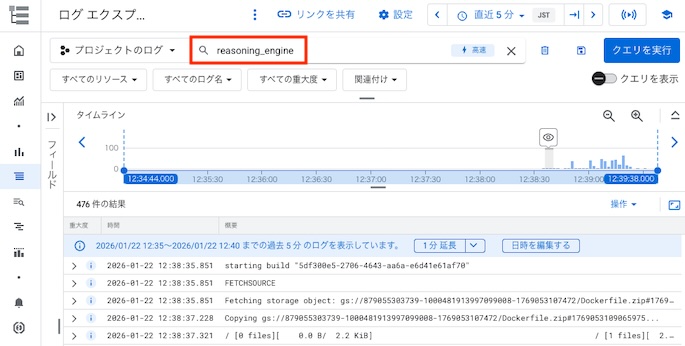

変数 `remote_adk_app` には、Agent Engine 上の `AdkApp` オブジェクトを呼び出すためのクライアントオブジェクトが格納されます。

`AdkApp` オブジェクトと同じメソッドが使用できるので、先ほどの簡易アプリがそのまま利用できます。

> デプロイ済みのエージェントを再利用する際は、次のように、エージェントのリソース名を指定してクライアントオブジェクトを取得します。
```
agent_runtime = vertexai.Client(
    project=PROJECT_ID,
    location=LOCATION
).agent_engines

remote_adk_app = agent_runtime.get(
    name=f'projects/{Project_ID}/locations/{LOCATION}/reasoningEngines/[Agent ID]'
)
```

In [19]:
chat_client = ChatClient(remote_adk_app)

query = '''
今年のゴールデンウィークは、何連休でしょうか？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

2026年のゴールデンウィークは、カレンダー通りであれば**5月2日（土）から5月6日（水・振替休日）までの5連休**となっています。

4月29日（水・昭和の日）は祝日ですが、その翌日からの2日間は平日となるため、カレンダー通りの休みであればゴールデンウィークの後半に5連休がまとまる形ですね。

もし有給休暇などを活用してうまく休みを繋げることができれば、さらに長い連休を楽しむことも可能ですよ。素敵なゴールデンウィークをお過ごしください！

In [20]:
query = '''
来年はどうなりますか？
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

来年、2027年のゴールデンウィークですね！

カレンダー通りの休みであれば、**5月1日（土）から5月5日（水・こどもの日）までの5連休**となります。

2027年の祝日の並びをもう少し詳しくお伝えしますね。
*   4月29日（木）は「昭和の日」で祝日ですが、翌日の4月30日（金）は平日のため、前半は1日だけの休日となります。
*   後半は5月1日（土）から5月5日（水）までがまとまったお休みになります。

もし有給休暇をうまく活用すれば、さらに連休を伸ばすこともできますよ！たとえば、4月30日（金）に有給を取れば、4月29日から5月5日まで7連休にすることも可能です。

今のうちから予定を立てておくと、より充実したお休みになりそうですね！

セッション情報も同様に取得できます。

取得したセッション情報は、ローカル実行の場合と異なり、初めから Python の辞書形式になっています。

In [21]:
user_id = chat_client.user_id
session_id = chat_client.session_id

print(f'User ID: {user_id}\nSession ID: {session_id}')

session = await chat_client.adk_app.async_get_session(
    user_id = user_id,
    session_id = session_id,
)

User ID: default_user
Session ID: 1375537631017828352


In [22]:
for event in session['events']:
    print(format_timestamp(event['timestamp']), event['author'])

2026-07-14 10:13:00.614276 user
2026-07-14 10:13:01.388593 search_agent
2026-07-14 10:13:04.075308 user
2026-07-14 10:13:04.299155 search_agent


In [23]:
search_queries = session['events'][1]['groundingMetadata']['webSearchQueries']
entry_point_html = session['events'][1]['groundingMetadata']['searchEntryPoint']['renderedContent']

print(search_queries)
display(HTML(entry_point_html))

['2026年 ゴールデンウィーク 何連休']


デプロイ済みエージェントの管理は、Cloud Console の [Agent Engines](https://console.cloud.google.com/vertex-ai/agents/agent-engines) のページから行います。

先ほどデプロイしたエージェントは、次のコマンドでも削除できます。

In [24]:
remote_adk_app.delete(force=True)